### x-ray 이미지에서 뼈의 윤곽선과 관절 경계를 검출
- 데이터 전처리 (CLAHE) : 이미지의 대비를 향상시켜 뼈의 구조를 더 잘 보이게
- 뼈 영역 마스킹 : 배경을 제거하고 분석 대상인 뼈 영역만 추출
- 엣지 검출 : Canny, Sobel, Laplacian 비교
- 결과 시각화 및 밀도 계산

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
IMG_DIR = os.path.join(BASE_DIR, "bone_sample", "boneage-training-dataset")
CSV_PATH = os.path.join(BASE_DIR, "bone_sample", "boneage-training-dataset.csv")
TARGET_SIZE = (512,512)
print(f'이미지 경로 : {IMG_DIR}')
print(f'csv 경로 : {CSV_PATH}')

이미지 경로 : C:\dev\workspace.python\medical_prep\bone\bone_sample\boneage-training-dataset
csv 경로 : C:\dev\workspace.python\medical_prep\bone\bone_sample\boneage-training-dataset.csv


In [3]:
df = pd.read_csv(CSV_PATH)
#연령대별 샘플 (boneage : 개월 수)
groups = {
    "baby_24m" : df[df["boneage"] <= 36].iloc[0],
    "child_84m" : df[(df["boneage"] >= 72) & (df["boneage"] <= 96) ].iloc[0],
    "teen_456m" : df[(df["boneage"] >= 144) & (df["boneage"] <= 168) ].iloc[0],
    "adult_216m" : df[df["boneage"] >= 210].iloc[0]
}
for nm, row in groups.items() :
    print(f"[{nm}] ID : {row['id']}, age : {row['boneage']}months, male : {row['male']}")

print(groups)

[baby_24m] ID : 1378, age : 12months, male : False
[child_84m] ID : 1379, age : 94months, male : False
[teen_456m] ID : 1383, age : 150months, male : True
[adult_216m] ID : 1466, age : 216months, male : True
{'baby_24m': id          1378
boneage       12
male       False
Name: 1, dtype: object, 'child_84m': id          1379
boneage       94
male       False
Name: 2, dtype: object, 'teen_456m': id         1383
boneage     150
male       True
Name: 6, dtype: object, 'adult_216m': id         1466
boneage     216
male       True
Name: 78, dtype: object}


In [4]:
#### CLAHE를 이용한 대비 향상 : 이미지의 국부적인 대비를 향상시켜 뼈의 미세한 구조를 부각시킴
#### Contrast Limited Adaptive Histogram Equalization

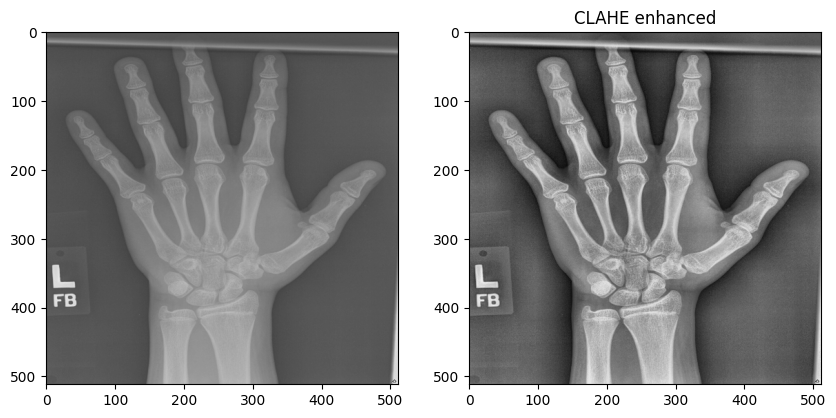

In [7]:
def preprocess(img) :
    #크기 조절
    resized = cv2.resize(img, TARGET_SIZE)
    # cliplimit : 히스토그램 값의 최대 허용치 2.0 : 부드러운 대비, 3.0: 일반적, 5: 이상 강한 대비
    # tileGridSize : 1개의 이미지를 8ㅌ8=64개 타일로
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(resized)
    return enhanced

# 샘플 이미지 테스트 child_84m
sample_id = groups["adult_216m"]["id"]
sample_path = os.path.join(IMG_DIR, f'{sample_id}.png')
img_orig = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
img_enhanced = preprocess(img_orig)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(cv2.resize(img_orig, TARGET_SIZE), cmap='gray')
plt.subplot(1,2,2); plt.imshow(cv2.resize(img_enhanced, TARGET_SIZE), cmap='gray')
plt.title('CLAHE enhanced')
plt.show()

#### 영역 마스킹

- 엣지 검출 시 배경의 노이즈를 제거하기 위해 이진화 사용하여 뼈영역의 마스크를 생성

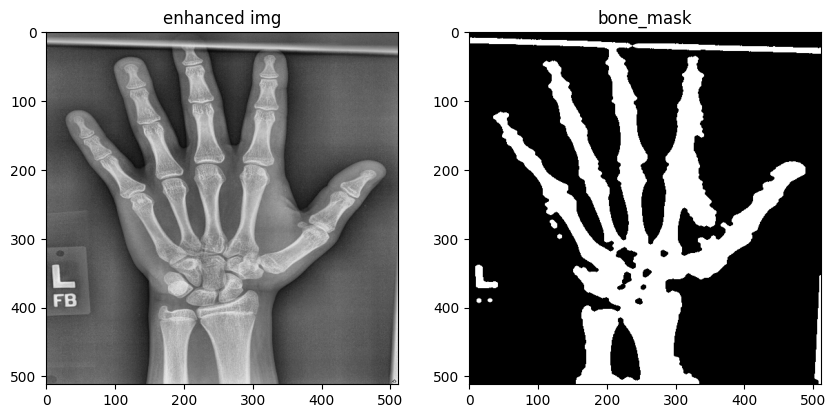

In [8]:
def sement_bone_region(img):
    #Otsu이진화 임계값 자동 결정
    _, mask = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    #노이즈 제거 및 구멍메우기
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    #내부의 작은 빈틈,구멍,끊어진부분 매움
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    #바깥쪽 작은 점 제거
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask

bone_mask = sement_bone_region(img_enhanced)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img_enhanced, cmap='gray'); plt.title('enhanced img')
plt.subplot(1,2,2); plt.imshow(bone_mask, cmap='gray');plt.title('bone_mask')
plt.show()


#### 엣지 검출 알고리즘 비교

- canny : 노이즈에 강하며 얇고 선명한 엣지 추출
- sobel : 이미지의 기울기를 이용하여 엣지 감도를 나타냄
- laplacian : 2차 미분을 활용하며 급격한 변화 일어나는 지점을 찾음

Text(0.5, 1.0, 'laplacian')

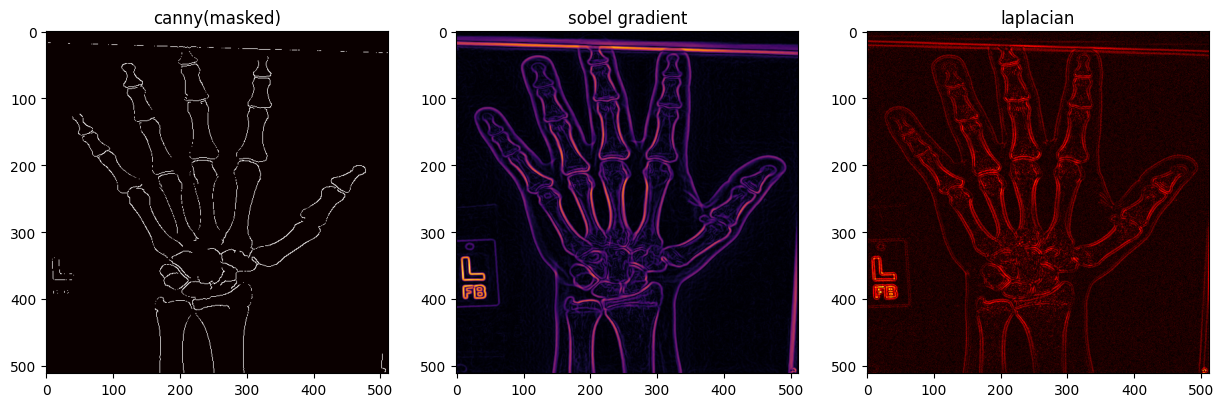

In [10]:
def detect_edges(img):
    blurred = cv2.GaussianBlur(img,(5,5),0)
    #canny
    median = np.median(blurred)
    low,high = int(max(0,0.4*median)), int(min(255,1.6*median))
    canny = cv2.Canny(blurred,low,high)
    #sobel
    sx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.uint8(cv2.normalize(np.sqrt(sx**2 + sy**2), None, 0, 255, cv2.NORM_MINMAX))
    #laplacian
    laplacian = cv2.convertScaleAbs(cv2.Laplacian(blurred, cv2.CV_64F))
    return canny, sobel, laplacian
canny,sobel,lap = detect_edges(img_enhanced)
#뼈 영역 내의 엣지만 남기기
canny_bone= cv2.bitwise_and(canny,bone_mask)
plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(canny_bone, cmap='hot');plt.title('canny(masked)')
plt.subplot(1,3,2); plt.imshow(sobel, cmap='inferno');plt.title('sobel gradient')
plt.subplot(1,3,3); plt.imshow(lap, cmap='hot');plt.title('laplacian')


In [15]:
def segment_bone_region(img):
    blur = cv2.GaussianBlur(img, (5,5), 0)
    _, mask = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    return mask

def analyze_bone_edge(img_path):
    #엣지 밀도를 계산
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    #전처리
    proc = preprocess(img)
    #마스킹
    mask=segment_bone_region(proc)
    #엣지 검출
    canny, _, _ = detect_edges(proc)
    canny_bone= cv2.bitwise_and(canny,mask)
    #엣지 밀도 계산(뼈 영역 대비 엣지 픽셀 비율)
    edge_pixels = np.sum(canny_bone>0)
    bone_pixels = np.sum(mask>0)
    density = (edge_pixels/bone_pixels)*100 if bone_pixels > 0 else 0
    return density
print('연령대별 엣지 밀도 분석')
for nm, row in groups.items():
    img_id = row['id']
    img_path = os.path.join(IMG_DIR, f'{img_id}.png')
    density = analyze_bone_edge(img_path)
    print(f'{nm} 분석완료:{round(density,2)}%')


연령대별 엣지 밀도 분석
baby_24m 분석완료:0.15%
child_84m 분석완료:1.73%
teen_456m 분석완료:4.54%
adult_216m 분석완료:7.31%
